In [88]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm.notebook import tqdm
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
from joblib import Parallel, delayed

In [2]:
dataset = pd.read_csv('AusAntidiabeticDrug.csv')

In [89]:
dataset.shape

(204, 2)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      204 non-null    object 
 1   y       204 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


In [5]:
dataset['ds'] = pd.to_datetime(dataset['ds'], errors='coerce')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      204 non-null    datetime64[ns]
 1   y       204 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


In [7]:
dataset

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
...,...,...
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510


## Serie Visualization

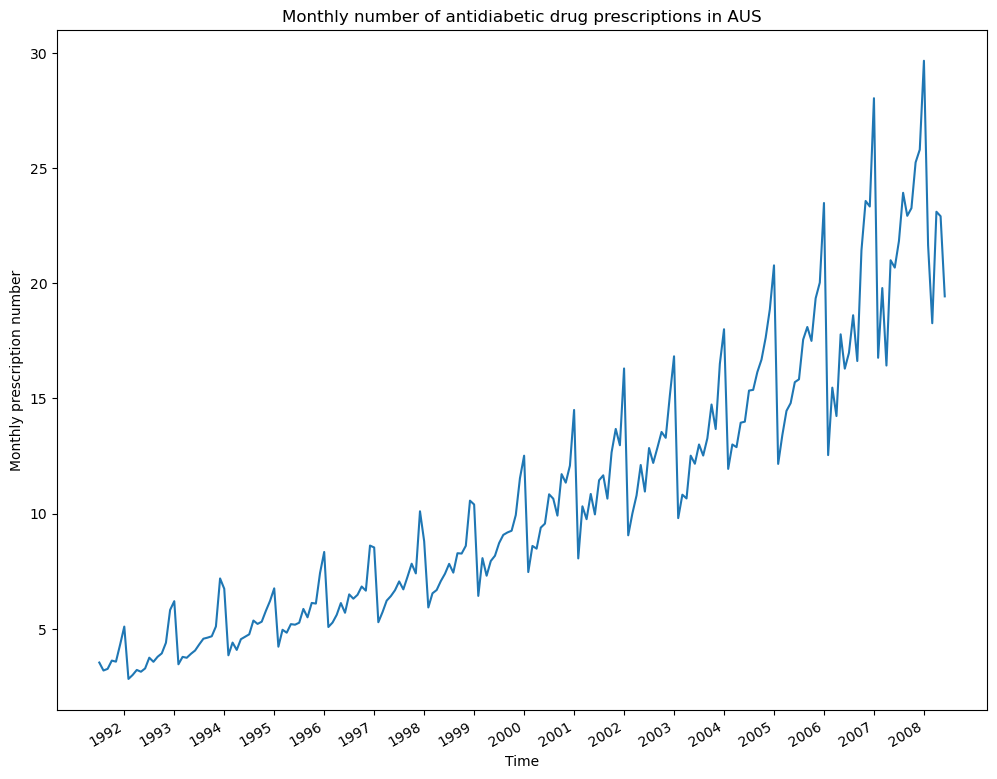

In [8]:
fig, ax = plt.subplots(figsize=(12,10))

ax.plot(dataset['y'])
ax.set_xlabel('Time')
ax.set_ylabel('Monthly prescription number')
plt.title('Monthly number of antidiabetic drug prescriptions in AUS')

plt.xticks(np.arange(6,203,12),np.arange(1992,2009,1))
fig.autofmt_xdate()
plt.show()

Presence of trendas the number of prescriptions raises and presence of seasonality

## Decomposition of the serie

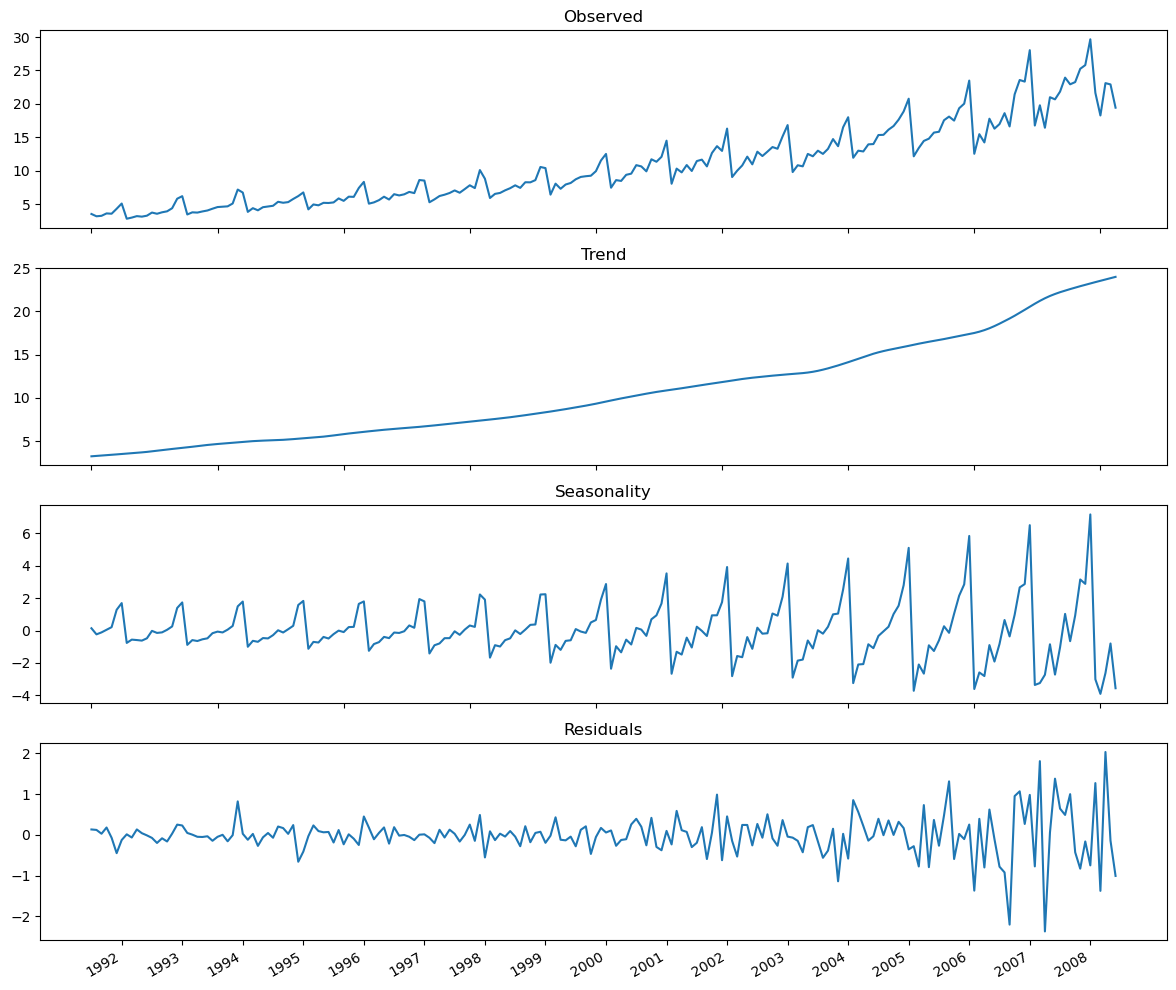

In [9]:
Decomp = STL(dataset['y'], period=12).fit()

fig, ax = plt.subplots(4,1, figsize=(12,10))

Decomp.observed.plot(ax=ax[0], title='Observed')
Decomp.trend.plot(ax=ax[1], title='Trend')
Decomp.seasonal.plot(ax=ax[2], title='Seasonality')
Decomp.resid.plot(ax=ax[3], title='Residuals')

plt.xticks(np.arange(6,203,12),np.arange(1992,2009,1))
fig.autofmt_xdate()

plt.tight_layout()

clear presence of trend, confirming the increase

clear seasonality showing the repeating pattern

Seasonality, no exog data, one var only

SARIMA is the suitable model for this case 

SARIMA(p,d,q)(P,D,Q,s)

## Modelisation

### Stationarity check

In [10]:
def adf_test(serie):
    test = adfuller(serie)

    print(f"Statistic: {test[0]}")
    print(f"P-value: {test[1]}")

    if test[1] > 0.05:
        print('Presence of unit root, the series isn\'t stationary')
    else:
        print('The serie is stationnary')

In [11]:
adf_test(dataset['y'])

Statistic: 3.1451856893067394
P-value: 1.0
Presence of unit root, the series isn't stationary


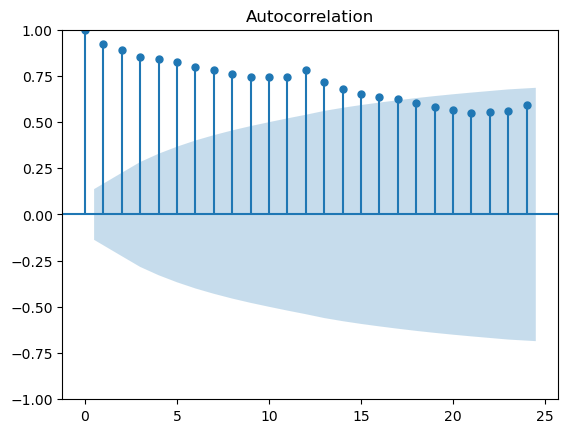

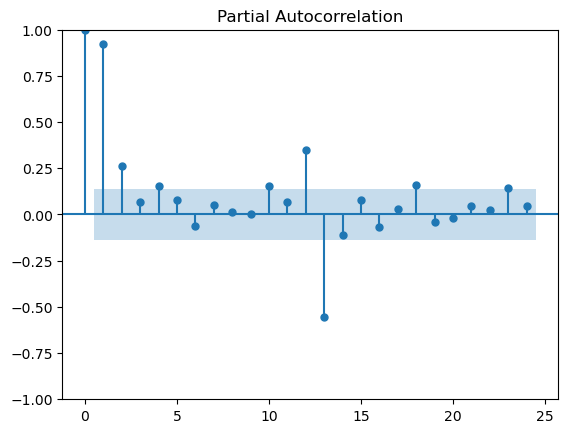

In [12]:
plot_acf(dataset['y'])
plot_pacf(dataset['y'])
plt.show()

ACF slowly decaying and staying high after lag 17

PACF cutting sharply after lag one, with lags 11 and 12 spiking which reflects the seasonality structure.

### apply transformation

In [13]:
diff_serie = np.diff(dataset['y'], n=1)
adf_test(diff_serie)

Statistic: -2.4951721474497086
P-value: 0.11665341686469533
Presence of unit root, the series isn't stationary


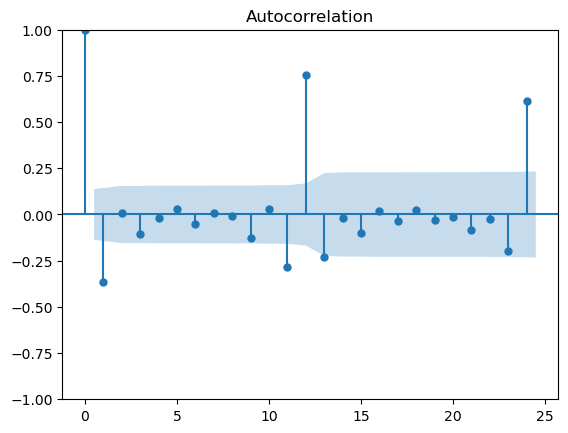

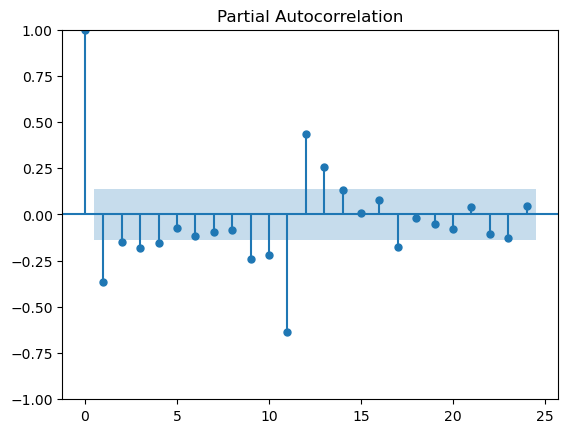

In [14]:
plot_acf(diff_serie)
plot_pacf(diff_serie)
plt.show()

In [15]:
seasonal_diff_serie = np.diff(diff_serie, n=12)
adf_test(seasonal_diff_serie)

Statistic: -19.84844009708471
P-value: 0.0
The serie is stationnary


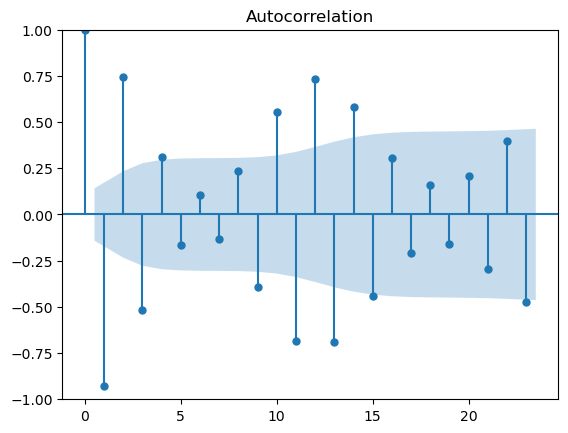

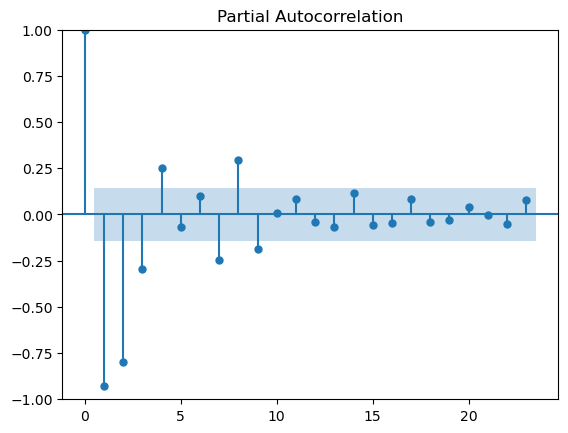

In [16]:
plot_acf(seasonal_diff_serie)
plot_pacf(seasonal_diff_serie)
plt.show()

seeing the plots, two bars appears spiking again more than the rest, lag 1 and lag 12. 1 repsenting months and 12 representing years (or seasonality leftover)

d = 1, D = 1, m=12

Our final model will be: SARIMA(p,1,q)(P,1,Q,12) 

In [17]:
train = dataset['y'][:168]
test = dataset['y'][168:]

In [18]:
print(f"Train:{len(train)} | Test:{len(test)}")

Train:168 | Test:36


### Holt Winter Model

In [90]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [99]:
HW_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
)

HW_result = HW_model.fit(
    smoothing_level=None,
    smoothing_trend=None,
    smoothing_seasonal=None,
    optimized=True
)

In [100]:
print(f'Alpha -> {HW_result.params['smoothing_level']}')
print(f'Beta -> {HW_result.params['smoothing_trend']}')
print(f'Omega -> {HW_result.params['smoothing_seasonal']}')

Alpha -> 0.20202841635661212
Beta -> 0.038652162229791974
Omega -> 0.0


<AxesSubplot: >

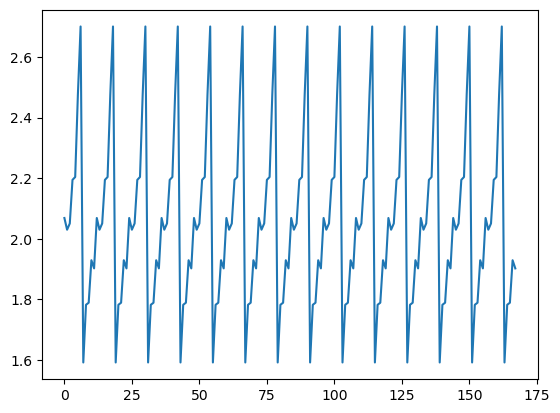

In [105]:
HW_result.season.plot()

In [102]:
HW_forecast = HW_result.forecast(steps=36)
HW_forecast

168    16.689398
169    16.493052
170    16.777745
171    18.080585
172    18.284561
173    20.690854
174    22.718196
175    13.472931
176    15.188085
177    15.348637
178    16.663530
179    16.538159
180    18.103820
181    17.881032
182    18.179850
183    19.581118
184    19.791599
185    22.384588
186    24.565287
187    14.560968
188    16.406435
189    16.571690
190    17.982601
191    17.838726
192    19.518242
193    19.269011
194    19.581955
195    21.081650
196    21.298637
197    24.078323
198    26.412378
199    15.649006
200    17.624784
201    17.794743
202    19.301672
203    19.139293
dtype: float64

### SARIMA Model

### Orders

In [31]:
p = range(0,5,1)
q = range(0,5,1)
P = range(0,5,1)
Q = range(0,5,1)

s = 12
d = 1
D = 1

orders = list(product(p,q,P,Q))

this total number of modesl is 625 models to be computed

it'll take very long since my laptop's capacities aren't very powerfull.

so instead i'll use joblib to speedup to process

writing this after trying both ways:

with joblib it took 70min to finish

without joblib it took +120min to finish

In [ ]:
def SARIMA(endog: Union[pd.Series, list], orders: list, d:int, D:int, s:int) -> pd.DataFrame:
    import warnings
    warnings.filterwarnings('ignore')    
    p,q,P,Q = orders
    try:
            Model = SARIMAX(endog, order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            simple_differencing=False).fit(disp=False)
            return [orders, Model.aic]
    except:
        return [orders, None]
results = Parallel(n_jobs=-1)( delayed(SARIMA)(train, order, d, D, s) for order in tqdm(orders) ) 
results = pd.DataFrame(results)
results.columns = ['(p,q,P,Q)', 'AIC']

In [25]:
results = results.sort_values(by='AIC', ascending=True).reset_index(drop=True)

In [26]:
results

,"(p,q,P,Q)",AIC
0,"(3, 1, 1, 3)",270.951096
1,"(2, 4, 1, 3)",271.229377
2,"(3, 3, 1, 3)",271.405907
3,"(4, 1, 1, 3)",272.145294
4,"(0, 4, 1, 3)",272.152380
...,...,...
620,"(0, 0, 0, 4)",351.680917
621,"(0, 0, 2, 4)",353.249284
622,"(0, 0, 0, 1)",354.751719
623,"(0, 0, 1, 0)",357.173706


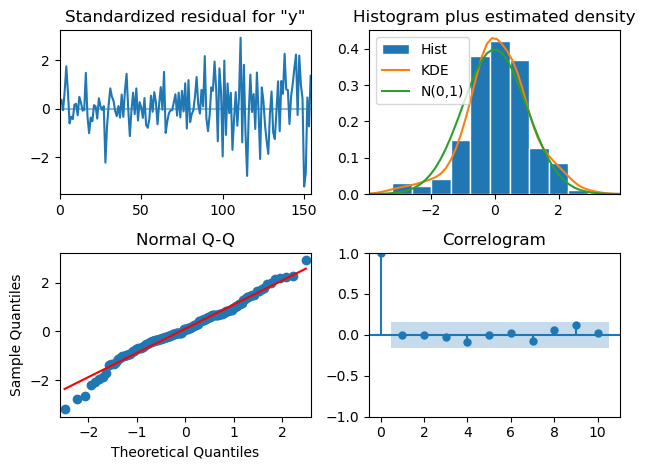

In [28]:
Final_Model = SARIMAX(train, order=(3,1,1), seasonal_order=(1,1,3,12), simple_differencing=False)
Results = Final_Model.fit(disp=False)
Results.plot_diagnostics()
plt.tight_layout()

### LJung-Box test

In [30]:
residuals = Results.resid
pvalue = acorr_ljungbox(residuals)
print(pvalue)

      lb_stat  lb_pvalue
1    0.436903   0.508621
2    0.627579   0.730673
3    0.646105   0.885801
4    2.258422   0.688349
5    2.950556   0.707609
6    3.389517   0.758606
7    9.982237   0.189582
8   10.592151   0.225896
9   11.854076   0.221661
10  11.985411   0.286034


all p_values > 0.05, failure to reject the null hypothesis, our residuals are independant (no autocorelation)

In [47]:
def Forecast_methods(df:pd.DataFrame, train_len:int, horizon:int, window:int, method:str) -> list:
    total_len = train_len + horizon
    results = []
    if method == "last":
        last_pred = []
        for i in range(train_len, total_len, window):
            last = df['y'][:i].iloc[-1]
            last_pred.extend(last for _ in range(window))
        return last_pred

    elif method == "last_season":
        last_season_pred = []
        for i in range(train_len, total_len, window):
            last_season = df['y'][i-window:i].values
            last_season_pred.extend(last_season)
        return last_season_pred

    elif method == "SARIMA":
        sarima_pred = []
        for i in range(train_len, total_len, window):
            Model = SARIMAX(df['y'][:i], order=(3,1,1),
            seasonal_order=(1,1,3,12), simple_differencing=False)
            result = Model.fit(disp=False)
            preds = result.get_prediction(0, i + window - 1)
            oos_preds = preds.predicted_mean.iloc[-window:]
            sarima_pred.extend(oos_preds)
        return sarima_pred

In [36]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 12

pred_df = dataset[168:]

In [49]:
pred_df['last'] = Forecast_methods(dataset, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_df['Last_season'] = Forecast_methods(dataset, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df['SARIMA'] = Forecast_methods(dataset, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

In [106]:
pred_df['Holt_Winter'] = HW_forecast

In [107]:
pred_df

,ds,y,Last_season,SARIMA,last,Holt_Winter
168,2005-07-01,15.829550,15.339097,16.745867,15.705248,16.689398
169,2005-08-01,17.554701,15.370764,16.619368,15.705248,16.493052
170,2005-09-01,18.100864,16.142005,17.255309,15.705248,16.777745
171,2005-10-01,17.496668,16.685754,18.107536,15.705248,18.080585
172,2005-11-01,19.347265,17.636728,18.722230,15.705248,18.284561
173,2005-12-01,20.031291,18.869325,19.885828,15.705248,20.690854
174,2006-01-01,23.486694,20.778723,22.216420,15.705248,22.718196
175,2006-02-01,12.536987,12.154552,13.544419,15.705248,13.472931
176,2006-03-01,15.467018,13.402392,14.972411,15.705248,15.188085
177,2006-04-01,14.233539,14.459239,15.593468,15.705248,15.348637


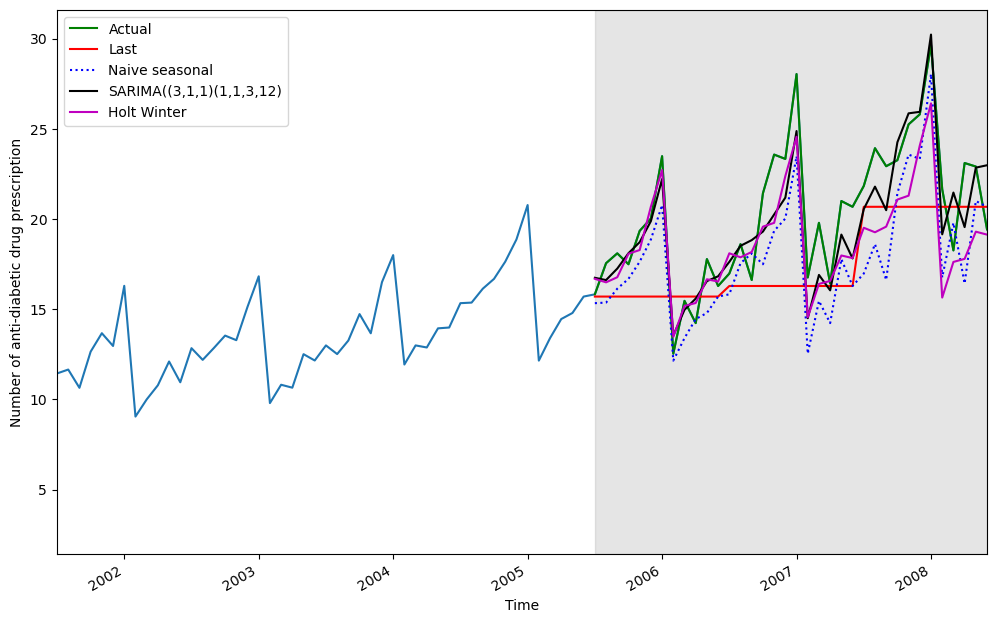

In [111]:
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(dataset['y'])
ax.plot(pred_df['y'], 'g-', label='Actual')
ax.plot(pred_df['last'], 'r-', label='Last')
ax.plot(pred_df['Last_season'], 'b:', label='Naive seasonal')
ax.plot(pred_df['SARIMA'], 'k-', label='SARIMA((3,1,1)(1,1,3,12)')
ax.plot(pred_df['Holt_Winter'], 'm-', label='Holt Winter')
ax.set_xlabel('Time')
ax.set_ylabel('Number of anti-diabetic drug prescription')
ax.axvspan(168, 203, color='grey', alpha=0.2)

plt.xticks(
    np.arange(6,203,12),
    np.arange(1992,2009,1)
    )
ax.set_xlim(120, 203)

fig.autofmt_xdate()
plt.legend()
plt.show()

In [113]:

mape_last_season = mape(pred_df['y'], pred_df['Last_season']) * 100
mape_sarima = mape(pred_df['y'], pred_df['SARIMA']) * 100
mape_last = mape(pred_df['y'], pred_df['last']) * 100
mape_hw = mape(pred_df['y'], pred_df['Holt_Winter']) * 100

print(f"Last_season: {mape_last_season:.2f}%")
print(f"SARIMA: {mape_sarima:.2f}%")
print(f"last: {mape_last:.2f}%")
print(f"Holt Winter: {mape_hw:.2f}%")

Last_season: 12.69%
SARIMA: 7.56%
last: 14.55%
Holt Winter: 9.40%


In [117]:
rmse_last_season = rmse(pred_df['y'], pred_df['Last_season'])
rmse_sarima = rmse(pred_df['y'], pred_df['SARIMA'])
rmse_last = rmse(pred_df['y'], pred_df['last'])
rmse_hw = rmse(pred_df['y'], pred_df['Holt_Winter'])

print(f"RMSE Last_season: {rmse_last_season:.2f}")
print(f"RMSE SARIMA:      {rmse_sarima:.2f}")
print(f"RMSE last:        {rmse_last:.2f}")
print(f"RMSE Holt Winter: {rmse_hw:.2f}")

RMSE Last_season: 3.15
RMSE SARIMA:      1.87
RMSE last:        4.15
RMSE Holt Winter: 2.52


In [116]:
mae_last_season = mae(pred_df['y'], pred_df['Last_season'])
mae_sarima = mae(pred_df['y'], pred_df['SARIMA'])
mae_last = mae(pred_df['y'], pred_df['last'])
mae_hw = mae(pred_df['y'], pred_df['Holt_Winter'])

print(f"MAE Last_season: {mae_last_season:.2f}")
print(f"MAE SARIMA:      {mae_sarima:.2f}")
print(f"MAE last:        {mae_last:.2f}")
print(f"MAE Holt Winter: {mae_hw:.2f}")

MAE Last_season: 2.66
MAE SARIMA:      1.53
MAE last:        3.18
MAE Holt Winter: 2.01


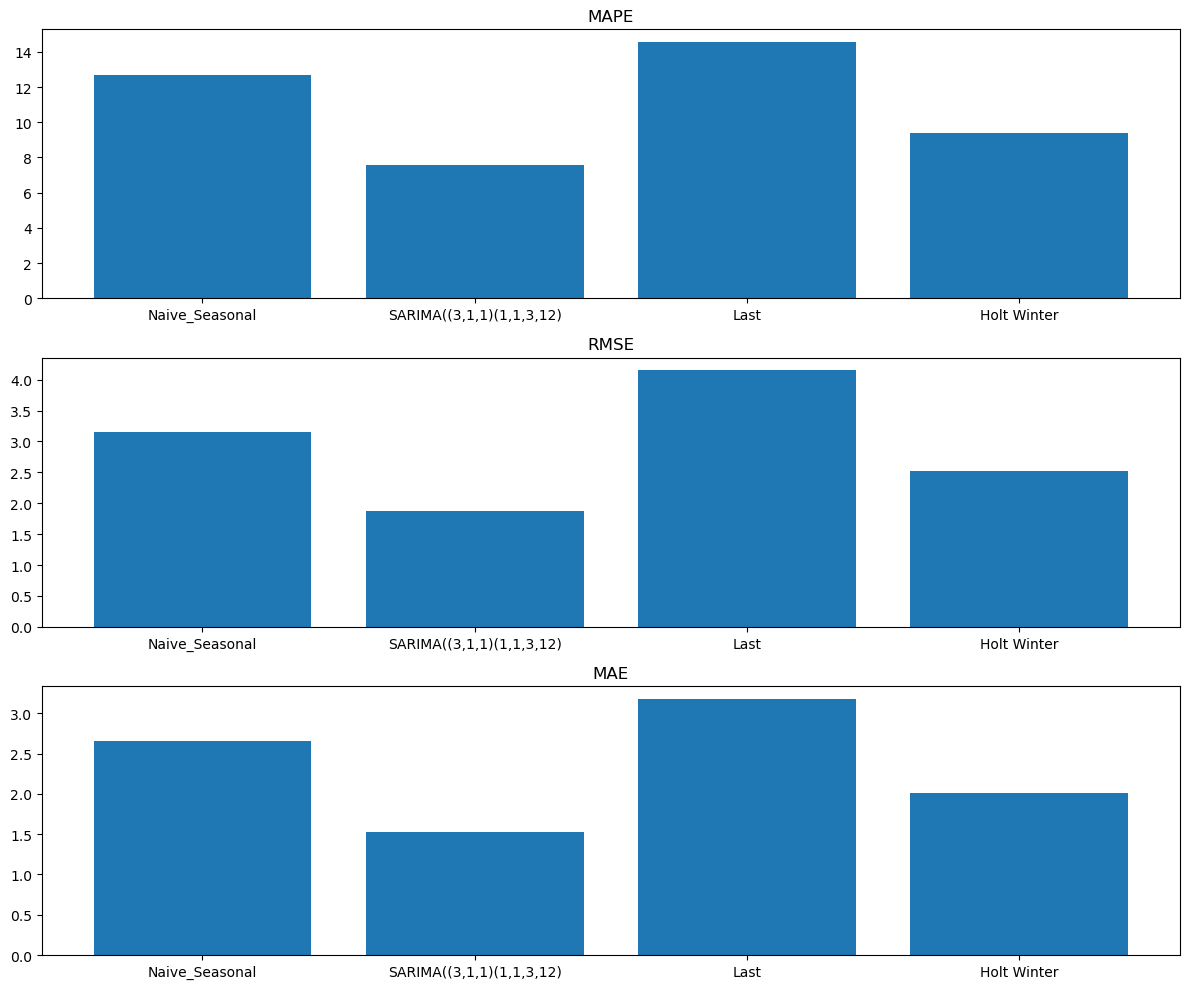

In [120]:
fig, (ax1,ax2,ax3) = plt.subplots(ncols=1, nrows=3, figsize=(12,10))

labels = ["Naive_Seasonal", 'SARIMA((3,1,1)(1,1,3,12)', 'Last', 'Holt Winter']
MAPE = [mape_last_season, mape_sarima, mape_last, mape_hw]
RMSE = [rmse_last_season, rmse_sarima, rmse_last, rmse_hw]
MAE  = [mae_last_season, mae_sarima, mae_last, mae_hw]

ax1.bar(labels, MAPE)
ax1.set_title('MAPE')

ax2.bar(labels, RMSE)
ax2.set_title('RMSE')

ax3.bar(labels, MAE)
ax3.set_title('MAE')

plt.tight_layout()

Seeing the plot and the metric's results, the SARIMA Model beats both of the baseline models. We can conclude that the SARIMA model is the suitable model to forecast the number of anti_diab drug prescription